[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brilliantbeaver/alexpose/blob/main/experiments/sjepa/gavd6-pm/00_sjepa_from_first_principles.ipynb)

# 00. S-JEPA from first principles

**The question this notebook answers.** What is S-JEPA, what exactly does it predict, and what does it deliberately refuse to predict? The target you should hit by the end is concrete: you can read notebook 04's training loop line by line without having to guess what any term means.

**What it assumes you already have.** Comfort with a Transformer encoder and with mini-batch gradient descent. It assumes no prior exposure to joint-embedding predictive architectures. Every term the rest of the series relies on is defined below, before it is used.

**What it produces.** No trained model, no dataset, and no scientific result. It produces three things: a vocabulary, a reference implementation small enough to read in one sitting, and one shape-and-gradient smoke test on a synthetic batch.

**What comes next.** Notebook 01 builds the GAVD manifest and downloads the source videos.

**Research use only.** This tutorial does not diagnose a person or validate a clinical device.

**Run it:** locally, use `uv sync` then `uv run jupyter lab` from this folder. In Colab, use the badge and run the setup cell. Restart the kernel after changing `experiments/sjepa/gavd6-pm/.env`.

**Keep the walk visible:** notebook 01 opens the source video, and notebook 02 shows frame, bbox, and skeleton alignment. Revisit those views whenever a latent or classifier result looks surprising.

## The ten steps

1. What a token is, and the vocabulary the whole series depends on.
2. Three methods that are easy to confuse, and why the confusion matters.
3. MAMP predicts normalized motion, not a teacher latent.
4. The 2026 MTM system is a separate hybrid design.
5. One paper-aligned core training step, in execution order.
6. The latent objective, written out.
7. What this adaptation keeps from the paper and what it changes.
8. The same ideas, now as runnable code.
9. One synthetic batch traced end to end.
10. What none of this licenses you to say, and what to read next.

### The two cells before step 1

The next cell is the shared setup cell, and every notebook in this series begins with the same one. It locates the repository root, loads `.env`, chooses between `smoke` mode (hand-authored motions that exercise code paths only) and `real` mode (the GAVD cohort), and prints the four paths that every later notebook reads from or writes to. Look at its printed `mode:` line before anything else, because the same code produces very differently meaningful numbers in the two modes. The executed copy below prints `mode: real`.

The cell after it draws `01_method_family.svg`, which maps where S-JEPA sits among the masked-modelling methods that step 2 pulls apart.


In [1]:
from pathlib import Path
import os
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/brilliantbeaver/alexpose.git"

if IN_COLAB:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "numpy", "pandas", "scipy", "scikit-learn", "matplotlib",
        "seaborn", "torch", "tqdm", "python-dotenv", "yt-dlp[default]",
        "opencv-python-headless", "mediapipe<1", "joblib", "pyarrow",
    ])
    clone_dir = Path("/content/alexpose")
    if not (clone_dir / ".git").exists():
        subprocess.check_call(["git", "clone", "--depth", "1", REPO_URL, str(clone_dir)])
    os.chdir(clone_dir)


def find_project_root(start=None):
    env_root = os.getenv("ALEXPOSE_ROOT")
    if env_root:
        candidate = Path(env_root).expanduser().resolve()
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
        print(f"Ignoring invalid ALEXPOSE_ROOT: {candidate}")
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
TUTORIAL_DIR = PROJECT_ROOT / "experiments" / "sjepa" / "gavd6-pm"

try:
    from dotenv import load_dotenv
    load_dotenv(TUTORIAL_DIR / ".env", override=False)
    load_dotenv(PROJECT_ROOT / ".env", override=False)
except Exception:
    pass

MODE = os.getenv("GAVD_MODE", "smoke").strip().lower()
if MODE not in {"smoke", "real"}:
    raise ValueError("GAVD_MODE must be smoke or real")
if MODE == "smoke":
    print(
        "SMOKE MODE: hand-authored motions test code paths only. "
        "They have no pathophysiological or clinical validity."
    )

PREFERRED_ROOT = Path(
    os.getenv(
        "GAVD4_ROOT",
        "/Users/pmui/vaults/worldmodels/gait/skeleton-jepa/gavd4",
    )
).expanduser()

requested_data = os.getenv("GAVD4_DATA_DIR") or os.getenv("GAVD_DATA_GAVD_DIR")
if requested_data and Path(requested_data).expanduser().exists():
    DATA_GAVD_DIR = Path(requested_data).expanduser()
elif requested_data:
    print(f"Ignoring missing GAVD CSV path: {Path(requested_data).expanduser()}")
    if (PREFERRED_ROOT / "data-gavd").exists():
        DATA_GAVD_DIR = PREFERRED_ROOT / "data-gavd"
    else:
        DATA_GAVD_DIR = PROJECT_ROOT / "data" / "gavd"
elif (PREFERRED_ROOT / "data-gavd").exists():
    DATA_GAVD_DIR = PREFERRED_ROOT / "data-gavd"
else:
    DATA_GAVD_DIR = PROJECT_ROOT / "data" / "gavd"

requested_youtube = os.getenv("GAVD4_YOUTUBE_DIR") or os.getenv("GAVD_YOUTUBE_DIR")
if requested_youtube:
    YOUTUBE_DIR = Path(requested_youtube).expanduser()
elif PREFERRED_ROOT.exists():
    YOUTUBE_DIR = PREFERRED_ROOT / "youtube"
else:
    YOUTUBE_DIR = PROJECT_ROOT / "experiments" / "sjepa" / "gavd6-pm" / "work" / "youtube"

CACHE_DIR = Path(
    os.getenv("GAVD_CACHE_DIR", TUTORIAL_DIR / "work" / "cache")
).expanduser()
ARTIFACT_ROOT = Path(
    os.getenv("GAVD_ARTIFACT_DIR", TUTORIAL_DIR / "work" / "artifacts")
).expanduser()
ARTIFACT_DIR = ARTIFACT_ROOT / MODE
POSE_DIR = ARTIFACT_DIR / "poses"

for folder in [CACHE_DIR, ARTIFACT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(CACHE_DIR / "matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(CACHE_DIR / "xdg-cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["XDG_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
from IPython.display import SVG, display


def show_tutorial_svg(filename):
    '''Render a repository SVG reliably in local Jupyter and Colab.'''
    path = TUTORIAL_DIR / "images" / filename
    if not path.exists():
        raise FileNotFoundError(
            f"Missing tutorial figure {path}. Clone the full alexpose repository."
        )
    display(SVG(filename=str(path)))

print(f"mode: {MODE}")
print(f"project: {PROJECT_ROOT}")
print(f"GAVD CSVs: {DATA_GAVD_DIR}")
print(f"YouTube cache: {YOUTUBE_DIR}")
print(f"artifacts: {ARTIFACT_DIR}")


mode: real
project: /Users/pmui/dev/alexpose
GAVD CSVs: /Users/pmui/dev/alexpose/data/gavd
YouTube cache: /Users/pmui/dev/alexpose/experiments/sjepa/gavd6/work/youtube
artifacts: /Users/pmui/dev/alexpose/experiments/sjepa/gavd6/work/artifacts/real


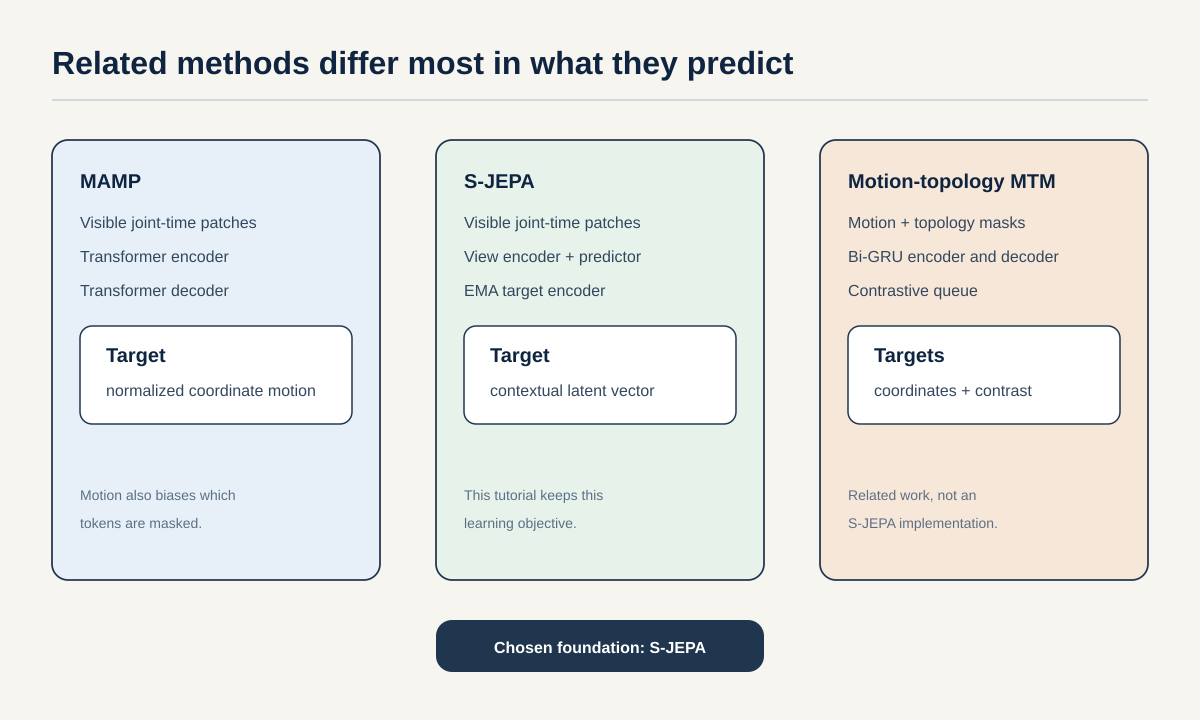

In [2]:
show_tutorial_svg("01_method_family.svg")


## Step 1 of 10. What a token is, and the vocabulary the series depends on

**The shortest useful definition.** S-JEPA sees an incomplete set of joint-time patches and predicts the target encoder's contextual latent vectors for the missing patches. It does not reconstruct coordinates and it does not forecast future frames.

That sentence rests entirely on the word *patch*, so define it before anything else. A joint-time patch contains one landmark across a short, non-overlapping temporal segment. With 64 frames, segment length 4, and 33 BlazePose joints:

\[
S = 64 / 4 = 16,\qquad N = 16 \times 33 = 528\text{ tokens}
\]

So one 64-frame skeleton clip becomes a bag of 528 tokens, in the same way a sentence becomes a bag of word tokens. From here on, every part of the model operates on those tokens rather than on raw coordinates.

### Vocabulary

Read this once now. Every later notebook uses these words with exactly these meanings, so a term that looks unfamiliar in notebook 04 or 06 will be defined here.

- **Sequence.** One annotated walking clip, resampled to a fixed number of frames. It is the unit the model consumes. It is not the unit of independent evidence; notebook 01 explains why the source video is.
- **Landmark**, also called a joint. One of the 33 BlazePose body points. Notebook 02 produces them from video.
- **Temporal segment.** A run of `segment_length` consecutive frames. Segments do not overlap, so segment boundaries partition the clip.
- **Token**, also called a joint-time patch. One landmark inside one segment, embedded into a vector. A clip contains `S` times `V` of them, where `S` is the number of segments and `V` the number of landmarks.
- **Latent**, also called an embedding. The vector a Transformer produces for a token. It is learned, it carries no units, and none of its axes is a coordinate.
- **View encoder**, called the *student* in the wider literature. The trainable Transformer. It sees only the tokens that were not removed.
- **Target encoder**, called the *teacher*. A copy of the view encoder with the same architecture, held frozen with respect to gradients. It receives the complete, unmasked sequence and is never updated by the optimizer.
- **EMA update.** After each optimizer step, every target-encoder weight is pulled a short way toward the matching view-encoder weight: `target = m * target + (1 - m) * view`, with momentum `m` close to 1. This is the only mechanism by which the target encoder ever changes, which is what makes the teacher a slowly moving average of the student rather than a second, independently trained network.
- **Target mask.** The boolean choice of which tokens are removed from the view encoder's input and therefore have to be predicted. `True` means hidden.
- **Mask token.** One learned vector, inserted at every hidden position before the predictor runs, so the predictor knows *where* the holes are without being told what was in them.
- **Predictor.** A second Transformer. It reads the view encoder's output for the visible tokens plus a mask token at each hidden position, and emits one vector per hidden position. That vector is what gets compared against the teacher.
- **Joint embedding.** The comparison happens between two embeddings, one from each encoder, and neither side is ever decoded back into pixels or coordinates. That is what the family name *joint embedding predictive architecture* refers to.
- **VICReg.** In this project VICReg means only the label-free invariance, variance-hinge, and covariance regularizer computed on projected student features. It never reads labels and it never reads the teacher.
- **Group loss.** A separate, label-aware term, used in Stages 1 through 4 only, equal to within-condition compactness plus a centroid-margin penalty. It is not part of VICReg, and notebook 04's abbreviated `group` log field prints only the centroid-margin penalty, not the whole group loss.
- **`std`.** In notebook 04's abbreviated log line, `std` is the mean feature standard deviation of unprojected EMA-teacher embeddings over the active corpus. It is a diagnostic that argues against total collapse. It is not a loss and not a VICReg component.

### Why predict a latent instead of the coordinates

If the objective were to reconstruct the missing coordinates, the model would have to spend capacity on everything that makes those coordinates exactly what they are: detector jitter, camera distance, clothing occlusion, the pixel-level accident of where one heel happened to land. A latent target moves that decision to the teacher. The student is only ever asked to agree with the teacher about the missing region, so any detail the teacher has already discarded costs the student nothing.

That is the argument for the design, and it is the reason this family exists. Whether it pays off on this particular cohort is a question for notebooks 05 and 06, not an assumption to carry forward from here.


## Step 2 of 10. Three methods that are easy to confuse

Before looking at the architecture, close one escape route. The phrase "masked skeleton modelling" covers at least three different methods, and the differences between them are not cosmetic: they change what gradient the encoder actually receives. If you are carrying the wrong one in your head, notebook 04's loop will look like it has a bug in it. This table separates them on the four axes that genuinely differ.

|Method|Mask input|Prediction target|Teacher branch|Training loss|
|---|---|---|---|---|
|MAMP, ICCV 2023|Visible joint-time patches|Segment-normalized temporal coordinate differences|None|Masked MSE|
|S-JEPA, ECCV 2024|Visible joint-time patches|Contextual target-encoder latent vectors|EMA target encoder|Soft-target cross-entropy|
|Motion-topology MTM, Scientific Reports 2026|Motion and topology body-part masks|Coordinate reconstruction plus contrastive representation|Momentum contrastive encoder|MSE plus InfoNCE and auxiliary loss|

Read the "Prediction target" column first, because that is the axis that matters most. Only S-JEPA predicts something that is itself learned and still moving while training runs. The other two regress a quantity that can be computed directly from the input.

The Nature-family paper is related work. It is not S-JEPA and its motion-topology sampler is prohibited in this experiment. Steps 3 and 4 walk through each of the two neighbours in enough detail that you can check for yourself that this project implements neither of them.


## Step 3 of 10. MAMP predicts normalized motion, not a teacher latent

Take the nearest neighbour first, because it is the one most often mistaken for S-JEPA. MAMP masks the same kind of joint-time patches, so the input side looks nearly identical. The difference is entirely on the output side.

MAMP forms temporal coordinate differences from a skeleton sequence and normalizes them within temporal segments. In simplified notation:

$$
\Delta X_{t,j} = X_{t+1,j} - X_{t,j}, \qquad
\widehat{\Delta X} = \frac{\Delta X - \mu_{\mathrm{segment}}}{\sigma_{\mathrm{segment}} + \epsilon}
$$

Its encoder receives visible coordinate patches. A Transformer decoder reconstructs the normalized motion at masked positions, and masked MSE supplies the gradient. The original method uses motion magnitude to favor informative targets. It has no EMA teacher, no target center, and no latent soft-target distribution. This tutorial explains the mechanism but never imports its motion-aware sampler.

### MAMP training loop, step by step

1. Split the skeleton into temporal joint patches and embed their coordinates.
2. Compute frame-to-frame motion and normalize it inside each temporal segment. This normalized motion is the reconstruction target, not the encoder input.
3. Rank or sample mask locations using motion magnitude in the original method.
4. Remove the masked coordinate patches and encode the visible patches with a Transformer.
5. Insert learned mask tokens, add their space-time positions, and run a lightweight Transformer decoder.
6. Read decoder outputs only at masked positions and regress normalized motion with mean squared error.
7. Backpropagate through both encoder and decoder. There is no stop-gradient teacher.

```text
coordinates -> visible patches -> Transformer encoder
coordinates -> normalized temporal differences ------------+
encoded visible patches + mask tokens -> decoder -> masked MSE
```

Two consequences follow, and both matter later. First, because the target is computed arithmetically from the input, MAMP cannot collapse in the way a joint-embedding method can, so it needs none of the centering, sharpening, or VICReg machinery that steps 5 through 7 introduce. Second, MAMP's motion-aware selection is part of the source method, but it is intentionally replaced here by uniform sampling over the fixed twelve-landmark set. Notebook 03 states that rule precisely and tests it.


## Step 4 of 10. The 2026 MTM system is a separate hybrid design

The second neighbour is further away, and it is worth reading mostly so you can recognise which of its parts this project deliberately does not adopt.

The Scientific Reports system combines a three-layer bidirectional GRU encoder with a two-layer GRU reconstruction decoder. Its mask probability blends topology and motion cues. Training includes masked coordinate MSE, a momentum query-key contrastive path with a queue, multi-level augmentations, a temporal-gated feature-difference module, and auxiliary divergence losses.

### MTM training loop, step by step

1. Partition joints into body parts and combine topology importance with observed motion to choose masked coordinates.
2. Feed the masked sequence to the bidirectional GRU query encoder and reconstruct missing coordinates with the GRU decoder.
3. Build a second augmented view for a momentum-updated key encoder. The query and key paths form the positive contrastive pair.
4. Compare the query representation with its positive key and queued negative keys using InfoNCE.
5. Compute temporal-gated feature differences and the paper's auxiliary divergence terms.
6. Add reconstruction, contrastive, and auxiliary losses, then update the query-side networks by gradient descent.
7. Update the key encoder from the query encoder by momentum and refresh the negative queue.

```text
masked sequence -> BiGRU query -> GRU decoder -> coordinate MSE
        |                |
        |                +-> query representation -> InfoNCE
augmented view -> momentum key encoder -> positive key + queue
```

Note the momentum key encoder in step 7. It looks like an EMA teacher and it is updated the same way, but it plays a different role: it supplies keys for a contrastive comparison against a queue of negatives, not a prediction target at masked positions. Do not read the two as the same mechanism.

Those components answer a different design question from S-JEPA's joint-token latent infilling. They are useful related ideas, but the blended motion-topology mask directly conflicts with this project's fixed twelve-landmark target rule, which is why it is excluded rather than merely unused.

This hybrid learns a useful representation while reconstructing coordinates. S-JEPA instead asks a predictor to match contextual teacher latents, and has no coordinate decoder and no negative queue.


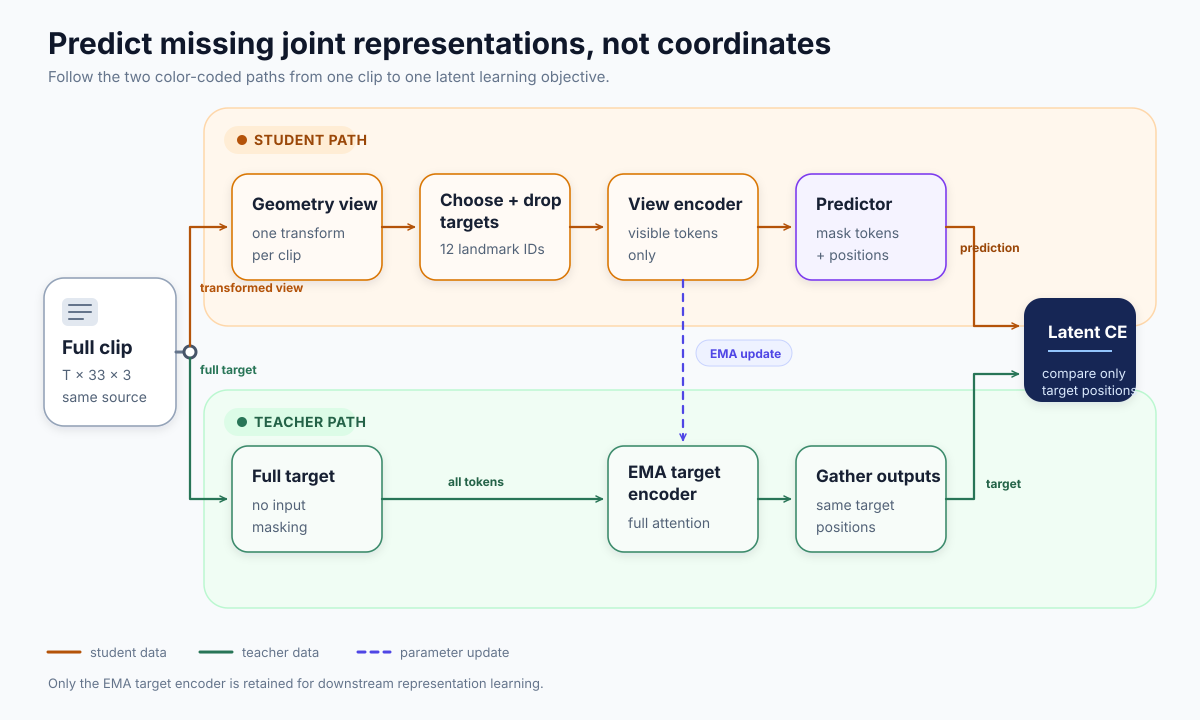

In [3]:
show_tutorial_svg("02_sjepa_architecture.svg")


## Step 5 of 10. One paper-aligned core training step

The figure above, `02_sjepa_architecture.svg`, is the same procedure drawn as a diagram. Here it is written out in execution order. Read it as a checklist: notebook 04's training loop performs exactly this sequence, in this order, and step 8 below shows the code for the core of it.

1. Convert the full sequence into one token per temporal segment and joint.
2. Send every token to the target encoder. Select target positions only after the encoder has used full self-attention, so that each target latent is contextual rather than a private encoding of one isolated patch.
3. Apply one sequence-wide geometric transform to create the view.
4. Remove the selected tokens before the trainable view encoder, so the view encoder genuinely never sees them.
5. Restore learned mask tokens at the missing positions.
6. Send the complete layout through a Transformer predictor.
7. Compare predicted and target distributions at the selected positions.
8. Regularize two views with VICReg, which here means only the label-free invariance, variance-hinge, and covariance regularizer on projected student features, so the representation keeps useful variance and avoids redundant dimensions.
9. After the normal-only stage, add the label-aware group loss, that is bounded within-condition compactness plus a centroid-margin penalty, so known groups are compact and their normalized centroids stay separated.
10. Update the view encoder, predictor, and VICReg projector by gradient descent.
11. Update the target encoder with an exponential moving average of the view encoder.
12. Update the running target center.

Two invariants deserve to be stated separately, because most implementation mistakes in this family break one of them.

- The target encoder never receives a masked input. If it did, the teacher's latent would describe a hole rather than the missing content, and the objective would be comparing the student's guess against a description of its own ignorance.
- The S-JEPA target mask is sampled uniformly from the 12 authorized landmarks only. Neither the mask nor its probability uses displacement, velocity, acceleration, or any other motion score. Notebook 03 defines that rule precisely and tests it adversarially.


## Step 6 of 10. The latent objective, written out

Item 7 of step 5 said "compare predicted and target distributions". This is that comparison, spelled out.

Let \(R_p\) be predictor output at the hidden positions, \(R_t\) be target-encoder output at the same positions, \(c\) be the running target center, and \(\tau_p,\tau_t\) be the predictor and target temperatures. The teacher's latent is centered by subtracting \(c\), sharpened by dividing by a small temperature, and turned into a distribution over the embedding dimensions:

\[
q = \operatorname{softmax}\left((R_t-c)/\tau_t\right)
\]

\[
\log p = \operatorname{logsoftmax}\left(R_p/\tau_p\right)
\]

\[
\mathcal{L} = -\frac{1}{M}\sum_{m=1}^{M} q_m^\top\log p_m
\]

Here \(M\) is the number of hidden positions in the batch, so the loss is a plain average of a cross-entropy taken one hidden token at a time.

**Why center and sharpen rather than take a plain distance.** Subtracting the running center \(c\) removes whatever all teacher latents currently share, which is exactly the direction a collapsing model would drift along. Dividing by \(\tau_t\), which is smaller than \(\tau_p\), makes the teacher's distribution the sharper of the two, so the student is asked to commit to a peak instead of copying a flat distribution. Together these two are the anti-collapse mechanism the paper relies on. This project does not rely on them alone, which is what step 7's VICReg row is about.

**Adaptation, disclosed.** The paper uses \(\tau_p=0.10\), \(\tau_t=0.06\), target-center momentum \(\beta=0.9\), and a target-encoder EMA that starts at 0.9999 and approaches 1.0. An EMA momentum of 0.9999 presumes tens of thousands of optimizer updates before the teacher has moved appreciably, and this tutorial runs far fewer, so it scales EMA to its much smaller number of optimizer updates. Smoke and quick-validation profiles start at 0.996. The recommended real profile starts at 0.999 and runs longer. These are documented adaptations, not claimed paper hyperparameters.


## Step 7 of 10. What this adaptation keeps and what it changes

Steps 5 and 6 described the paper. This step is the honest diff between the paper and what notebook 04 actually runs, so that nothing in the later notebooks arrives as a surprise. Read the right-hand column: every row that does not say "Same" is a place where a result here cannot be attributed to the published method.

|Component|ECCV S-JEPA|This GAVD tutorial|
|---|---|---|
|Token|One joint over 4 frames|Same|
|View encoder|Transformer over visible tokens|Same|
|Target encoder|Full input, EMA update|Same|
|Predictor|Transformer with mask tokens|Same|
|JEPA loss|Centered and sharpened latent cross-entropy|Same|
|Mask sampler|Motion-aware, 90 percent global mask|Uniform within 12 permitted BlazePose landmarks; motion is never scored|
|Anti-collapse|Teacher centering and sharpening|Teacher controls plus an explicit VICReg invariance, variance, and covariance regularizer|
|Condition separation|Not part of the paper|A bounded, label-aware group loss after Stage 0: within-condition compactness plus a centroid-margin penalty|
|Skeleton|Ground-truth 3D, 25 joints|Monocular BlazePose x, y, relative z, 33 joints|
|View augmentation|3D vertical-axis rotation and random temporal crop|Relative-coordinate vertical-axis rotation and translation; no random temporal crop|
|Downstream|Target encoder|Freeze only after the final curriculum stage, with documented pooling|

The mask list comes only from `experiments/multiple-sclerosis/mapping-data/ms-pd-mapping.md`. The valid-eligible ratio uses trackable positions among those 12 joints; the global ratio describes all 33 joints. The implementation never fills a quota with a forbidden joint. Notebook 03 is where those two ratios are computed and where the difference between them is made concrete.

### The required training order

The curriculum below is the second large departure from the paper, and it is the one that most affects how later results may be read. Each row is a stage; a stage is a contiguous block of optimizer updates over a fixed set of conditions.

|Stage|Data available to optimization|What continues from the prior stage|
|---:|---|---|
|0|`normal` only|Fresh view encoder and predictor|
|1|`normal + parkinsons`|Same model, EMA teacher, center, and VICReg projector|
|2|`normal + parkinsons + stroke`|Same state; balanced replay of earlier groups|
|3|`normal + parkinsons + stroke + myopathic`|Same state; balanced replay of earlier groups|
|4|`normal + parkinsons + stroke + myopathic + cerebralpalsy`|Same state; freeze only after this stage|

Two things follow that you should carry into every later notebook.

First, VICReg prevents collapse, but VICReg alone does **not** guarantee that condition groups move apart, because VICReg never sees a label. That is precisely why Stages 1 through 4 add the separate label-aware group loss. Those stages are therefore representation fine-tuning, not fully label-free self-supervised learning, and should never be described as the latter.

Second, because Stage 4 sees every condition, the encoder has been exposed to every sequence that any later notebook evaluates. Every score in this package is therefore **transductive**. That is a property of this design, not an accident, and it must be disclosed wherever a number is quoted.


## Step 8 of 10. The same ideas, now as runnable code

Everything above was prose. The next five code cells turn it into a small, complete implementation, so that step 9 can actually run it. Nothing here is trained and nothing here is a result; read these cells as the definitions that steps 1 through 7 have been describing.

They arrive in dependency order:

1. **The landmark contract.** `BLAZEPOSE_33` names all 33 landmarks in index order, and `MASK_KEYPOINTS` lists the 12 that are eligible to become prediction targets. The two `assert` statements are the point of the cell: they fail loudly if the index list and the name list ever drift apart.
2. **A synthetic corpus.** `synthetic_gait_sequence` builds a hand-authored walk so the code paths can be exercised with no video and no download. Its own docstring calls it a code-path fixture, and that is exactly what it is. It has no pathophysiological validity, so no number computed from it is ever a gait finding.
3. **Preprocessing.** `interpolate_low_visibility` fills only short internal gaps and keeps a validity mask, so a landmark the detector never found cannot silently become a prediction target. `center_and_scale` moves the origin to the pelvis and divides by body scale, which is what makes two people at different camera distances comparable. `temporal_resize` puts every clip on the same frame count. `prepare_sequence` chains the three.
4. **The mask sampler.** `uniform_neurologic_mask` implements the rule from step 5's second invariant, and `mask_audit` reports what it actually did. Notebook 03 is dedicated to this function; here it is only needed so that step 9 has a mask to use.
5. **The model.** `SkeletonPatchEncoder` is the encoder used for both the view and target roles, `SkeletonPredictor` holds the mask token and fills the holes, and `SJEPAGait` wires them together with `update_target` for the EMA step and `update_center` for the running center. `sjepa_cross_entropy` is the loss from step 6 and `cosine_ema` is the momentum schedule. `geometric_view` is the sequence-wide transform from step 5 item 3; note that its `flip_probability` defaults to 0, because a left-right flip would destroy exactly the laterality that matters for a condition such as stroke.


In [4]:
BLAZEPOSE_33 = [
    "NOSE", "LEFT_EYE_INNER", "LEFT_EYE", "LEFT_EYE_OUTER",
    "RIGHT_EYE_INNER", "RIGHT_EYE", "RIGHT_EYE_OUTER", "LEFT_EAR",
    "RIGHT_EAR", "MOUTH_LEFT", "MOUTH_RIGHT", "LEFT_SHOULDER",
    "RIGHT_SHOULDER", "LEFT_ELBOW", "RIGHT_ELBOW", "LEFT_WRIST",
    "RIGHT_WRIST", "LEFT_PINKY", "RIGHT_PINKY", "LEFT_INDEX",
    "RIGHT_INDEX", "LEFT_THUMB", "RIGHT_THUMB", "LEFT_HIP",
    "RIGHT_HIP", "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE",
    "RIGHT_ANKLE", "LEFT_HEEL", "RIGHT_HEEL", "LEFT_FOOT_INDEX",
    "RIGHT_FOOT_INDEX",
]
MASK_KEYPOINTS = [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
MASK_KEYPOINT_NAMES = [
    "LEFT_SHOULDER", "RIGHT_SHOULDER", "LEFT_HIP", "RIGHT_HIP",
    "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE", "RIGHT_ANKLE",
    "LEFT_HEEL", "RIGHT_HEEL", "LEFT_FOOT_INDEX", "RIGHT_FOOT_INDEX",
]
assert MASK_KEYPOINTS == sorted(set(MASK_KEYPOINTS))
assert [BLAZEPOSE_33[i] for i in MASK_KEYPOINTS] == MASK_KEYPOINT_NAMES


In [5]:
def synthetic_gait_sequence(condition="normal", frames=64, seed=0):
    '''Create a code-path fixture, not a physiological disease simulation.'''
    rng = np.random.default_rng(seed)
    phase = np.linspace(0.0, 4.0 * np.pi, frames, endpoint=False)
    seq = np.zeros((frames, 33, 4), dtype=np.float32)
    seq[..., 3] = 1.0
    base = {
        11: (0.42, 0.28), 12: (0.58, 0.28),
        23: (0.45, 0.52), 24: (0.55, 0.52),
        25: (0.44, 0.70), 26: (0.56, 0.70),
        27: (0.43, 0.89), 28: (0.57, 0.89),
        29: (0.42, 0.92), 30: (0.58, 0.92),
        31: (0.39, 0.94), 32: (0.61, 0.94),
    }
    for joint, (x, y) in base.items():
        seq[:, joint, 0] = x
        seq[:, joint, 1] = y
    amplitude = 0.045
    lift = 0.025
    if condition == "parkinsons":
        amplitude *= 0.45
        lift *= 0.45
    if condition == "myopathic":
        seq[:, [11, 12], 0] += 0.03 * np.sin(phase)[:, None]
        seq[:, [23, 24], 0] += 0.018 * np.sin(phase)[:, None]
    for joint, knee, foot, offset in [(27, 25, 31, 0.0), (28, 26, 32, np.pi)]:
        wave = np.sin(phase + offset)
        if condition == "stroke" and joint == 27:
            wave = 0.35 * wave
        if condition == "cerebralpalsy":
            seq[:, knee, 1] -= 0.045
            seq[:, joint, 1] -= 0.02
        seq[:, joint, 0] += amplitude * wave
        seq[:, knee, 0] += 0.4 * amplitude * wave
        seq[:, foot, 0] += amplitude * wave
        seq[:, joint, 1] -= lift * np.maximum(wave, 0.0)
        seq[:, foot, 1] -= 0.7 * lift * np.maximum(wave, 0.0)
    seq[..., :3] += rng.normal(0.0, 0.0025, seq[..., :3].shape)
    return seq


def synthetic_corpus(conditions=None, n_per_condition=10, frames=64, seed=42):
    if conditions is None:
        conditions = [
            "normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"
        ]
    records = []
    counter = 0
    for condition in conditions:
        for sample in range(n_per_condition):
            records.append({
                "condition": condition,
                "sequence_id": f"smoke_{condition}_{sample:03d}",
                "video_id": f"smoke_video_{condition}_{sample // 2:02d}",
                "sequence": synthetic_gait_sequence(
                    condition=condition,
                    frames=frames,
                    seed=seed + counter,
                ),
            })
            counter += 1
    return records


In [6]:
def interpolate_low_visibility(sequence, threshold=0.45, max_gap=4):
    '''Fill only short internal gaps and preserve the original validity mask.

    Long gaps and sequence ends are never extrapolated. Their coordinates remain
    missing until center_and_scale converts them to an explicit zero sentinel.
    They can never become S-JEPA prediction targets.
    '''
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
        raise ValueError(f"Expected [T, 33, 4], received {sequence.shape}")
    visibility = np.nan_to_num(sequence[..., 3], nan=0.0)
    finite = np.isfinite(sequence[..., :3]).all(axis=-1)
    valid = (visibility >= threshold) & finite
    filled = valid.copy()
    for joint in range(33):
        observed = np.flatnonzero(valid[:, joint])
        for left, right in zip(observed[:-1], observed[1:]):
            gap = int(right - left - 1)
            if not 0 < gap <= max_gap:
                continue
            fraction = (
                np.arange(1, gap + 1, dtype=np.float32) / (gap + 1)
            )[:, None]
            sequence[left + 1:right, joint, :3] = (
                sequence[left, joint, :3][None, :] * (1.0 - fraction)
                + sequence[right, joint, :3][None, :] * fraction
            )
            filled[left + 1:right, joint] = True
        sequence[~filled[:, joint], joint, :3] = np.nan
    sequence[..., 3] = visibility
    return sequence, valid


def center_and_scale(sequence, eps=1e-6):
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    xyz = sequence[..., :3]
    left_hip, right_hip = xyz[:, 23], xyz[:, 24]
    left_ok = np.isfinite(left_hip).all(axis=1)
    right_ok = np.isfinite(right_hip).all(axis=1)
    pelvis = np.full((len(xyz), 3), np.nan, dtype=np.float32)
    pelvis[left_ok & right_ok] = 0.5 * (
        left_hip[left_ok & right_ok] + right_hip[left_ok & right_ok]
    )
    pelvis[left_ok & ~right_ok] = left_hip[left_ok & ~right_ok]
    pelvis[right_ok & ~left_ok] = right_hip[right_ok & ~left_ok]
    pelvis_ok = np.isfinite(pelvis).all(axis=1)
    fallback = np.median(pelvis[pelvis_ok], axis=0) if pelvis_ok.any() else np.zeros(3)
    pelvis[~np.isfinite(pelvis).all(axis=1)] = fallback
    xyz = xyz - pelvis[:, None, :]
    shoulder_width = np.linalg.norm(xyz[:, 11, :2] - xyz[:, 12, :2], axis=-1)
    hip_width = np.linalg.norm(xyz[:, 23, :2] - xyz[:, 24, :2], axis=-1)
    body_scale = np.nanmedian(np.maximum(shoulder_width, hip_width))
    if not np.isfinite(body_scale) or body_scale < eps:
        body_scale = 1.0
    sequence[..., :3] = np.nan_to_num(
        xyz / body_scale, nan=0.0, posinf=0.0, neginf=0.0
    )
    return np.nan_to_num(sequence, nan=0.0, posinf=0.0, neginf=0.0)


def temporal_resize(array, frames):
    array = np.asarray(array)
    if len(array) == frames:
        return array.copy()
    if len(array) < 2:
        return np.repeat(array, frames, axis=0)
    old_t = np.linspace(0.0, 1.0, len(array))
    new_t = np.linspace(0.0, 1.0, frames)
    flat = array.reshape(len(array), -1)
    resized = np.stack(
        [np.interp(new_t, old_t, flat[:, i]) for i in range(flat.shape[1])],
        axis=1,
    )
    return resized.reshape(frames, *array.shape[1:]).astype(array.dtype)


def prepare_sequence(
    sequence,
    frames=64,
    visibility_threshold=0.45,
    max_gap=4,
):
    cleaned, valid = interpolate_low_visibility(
        sequence, visibility_threshold, max_gap=max_gap
    )
    cleaned = center_and_scale(cleaned)
    cleaned = temporal_resize(cleaned, frames)
    valid = temporal_resize(valid.astype(np.float32), frames) >= 0.5
    return cleaned[..., :3].astype(np.float32), valid.astype(bool)


In [7]:
def uniform_neurologic_mask(valid_patch, mask_fraction=0.60, seed=None):
    """Sample eligible joint-time tokens uniformly, without motion scores.

    valid_patch has shape [B, S, V]. True means that a patch can be a target.
    The returned mask has the same shape. True means hidden from the view encoder.
    """
    valid_patch = np.asarray(valid_patch, dtype=bool)
    if valid_patch.ndim != 3 or valid_patch.shape[2] != 33:
        raise ValueError(f"Expected [B, S, 33], received {valid_patch.shape}")
    if not 0.0 < mask_fraction < 1.0:
        raise ValueError("mask_fraction must be between 0 and 1")
    rng = np.random.default_rng(seed)
    eligible_joint = np.zeros(33, dtype=bool)
    eligible_joint[MASK_KEYPOINTS] = True
    eligible = valid_patch & eligible_joint[None, None, :]
    counts = eligible.reshape(len(eligible), -1).sum(axis=1)
    if np.any(counts < 2):
        raise ValueError("Each sample needs at least two valid eligible tokens")
    n_mask = max(1, int(np.floor(counts.min() * mask_fraction)))
    n_mask = min(n_mask, int(counts.min()) - 1)
    mask = np.zeros_like(eligible)
    for batch_index in range(len(mask)):
        candidates = np.flatnonzero(eligible[batch_index].reshape(-1))
        chosen = rng.choice(candidates, size=n_mask, replace=False)
        mask[batch_index].reshape(-1)[chosen] = True
    forbidden = sorted(set(range(33)).difference(MASK_KEYPOINTS))
    assert not mask[:, :, forbidden].any()
    assert mask.reshape(len(mask), -1).any(axis=1).all()
    assert (~mask).reshape(len(mask), -1).any(axis=1).all()
    return mask


def mask_audit(mask, valid_patch):
    mask = np.asarray(mask, dtype=bool)
    valid_patch = np.asarray(valid_patch, dtype=bool)
    eligible_joint = np.zeros(33, dtype=bool)
    eligible_joint[MASK_KEYPOINTS] = True
    eligible = valid_patch & eligible_joint[None, None, :]
    masked_counts = mask.reshape(len(mask), -1).sum(axis=1)
    eligible_counts = eligible.reshape(len(mask), -1).sum(axis=1)
    per_sample_ratio = masked_counts / eligible_counts
    touched = np.flatnonzero(mask.any(axis=(0, 1))).tolist()
    return {
        "masked_keypoints": touched,
        "masked_names": [BLAZEPOSE_33[i] for i in touched],
        "global_fraction": float(mask.mean()),
        "eligible_mask_fraction_min": float(per_sample_ratio.min()),
        "eligible_mask_fraction_mean": float(per_sample_ratio.mean()),
        "eligible_mask_fraction_max": float(per_sample_ratio.max()),
        "forbidden_count": int(mask[:, :, sorted(set(range(33)) - set(MASK_KEYPOINTS))].sum()),
    }


In [8]:
import copy
import math
import torch
from torch import nn


class SkeletonPatchEncoder(nn.Module):
    def __init__(
        self,
        frames=64,
        joints=33,
        coordinate_dim=3,
        segment_length=4,
        embed_dim=64,
        depth=2,
        heads=4,
        dropout=0.0,
    ):
        super().__init__()
        if frames % segment_length:
            raise ValueError("frames must be divisible by segment_length")
        self.frames = frames
        self.joints = joints
        self.coordinate_dim = coordinate_dim
        self.segment_length = segment_length
        self.segments = frames // segment_length
        self.embed_dim = embed_dim
        self.patch_embed = nn.Linear(segment_length * coordinate_dim, embed_dim)
        self.time_pos = nn.Parameter(torch.randn(self.segments, embed_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(joints, embed_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)

    def patchify(self, x):
        batch, frames, joints, channels = x.shape
        expected = (self.frames, self.joints, self.coordinate_dim)
        if (frames, joints, channels) != expected:
            raise ValueError(f"Expected [B, {expected}], received {x.shape}")
        patches = x.reshape(
            batch, self.segments, self.segment_length, joints, channels
        )
        patches = patches.permute(0, 1, 3, 2, 4).contiguous()
        return patches.flatten(3)

    def positioned_tokens(self, x):
        tokens = self.patch_embed(self.patchify(x))
        return (
            tokens
            + self.time_pos[None, :, None, :]
            + self.joint_pos[None, None, :, :]
        )

    def forward(self, x, keep_mask=None):
        tokens = self.positioned_tokens(x)
        batch = len(tokens)
        flat = tokens.reshape(batch, self.segments * self.joints, self.embed_dim)
        if keep_mask is not None:
            keep_mask = keep_mask.reshape(batch, -1)
            kept_per_sample = keep_mask.sum(dim=1)
            if not torch.equal(kept_per_sample, kept_per_sample[:1].expand_as(kept_per_sample)):
                raise ValueError("Each sample must keep the same number of tokens")
            flat = flat[keep_mask].reshape(batch, int(kept_per_sample[0]), self.embed_dim)
        return self.norm(self.blocks(flat))


class SkeletonPredictor(nn.Module):
    def __init__(
        self,
        segments,
        joints,
        encoder_dim=64,
        predictor_dim=64,
        depth=2,
        heads=4,
        dropout=0.0,
    ):
        super().__init__()
        self.segments = segments
        self.joints = joints
        self.encoder_to_predictor = nn.Linear(encoder_dim, predictor_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, predictor_dim))
        nn.init.normal_(self.mask_token, std=0.02)
        self.time_pos = nn.Parameter(torch.randn(segments, predictor_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(joints, predictor_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=predictor_dim,
            nhead=heads,
            dim_feedforward=predictor_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(predictor_dim)
        self.output = nn.Linear(predictor_dim, encoder_dim)

    def forward(self, visible_features, target_mask):
        batch = len(visible_features)
        target_mask = target_mask.reshape(batch, self.segments * self.joints)
        visible_mask = ~target_mask
        visible = self.encoder_to_predictor(visible_features)
        full = self.mask_token.expand(
            batch, self.segments * self.joints, -1
        ).clone()
        full[visible_mask] = visible.reshape(-1, visible.shape[-1])
        positions = (
            self.time_pos[:, None, :] + self.joint_pos[None, :, :]
        ).reshape(1, self.segments * self.joints, -1)
        full = full + positions
        predicted = self.output(self.norm(self.blocks(full)))
        return predicted[target_mask].reshape(batch, -1, predicted.shape[-1])


class SJEPAGait(nn.Module):
    def __init__(
        self,
        frames=64,
        joints=33,
        coordinate_dim=3,
        segment_length=4,
        embed_dim=64,
        encoder_depth=2,
        predictor_depth=2,
        heads=4,
    ):
        super().__init__()
        self.view_encoder = SkeletonPatchEncoder(
            frames, joints, coordinate_dim, segment_length,
            embed_dim, encoder_depth, heads,
        )
        self.target_encoder = copy.deepcopy(self.view_encoder)
        for parameter in self.target_encoder.parameters():
            parameter.requires_grad_(False)
        self.predictor = SkeletonPredictor(
            self.view_encoder.segments,
            joints,
            embed_dim,
            embed_dim,
            predictor_depth,
            heads,
        )
        self.register_buffer("target_center", torch.zeros(embed_dim))

    def forward(self, view, target, target_mask):
        visible_features = self.view_encoder(view, keep_mask=~target_mask)
        predicted = self.predictor(visible_features, target_mask)
        with torch.no_grad():
            all_targets = self.target_encoder(target)
            flat_mask = target_mask.reshape(len(target), -1)
            selected = all_targets[flat_mask].reshape(
                len(target), -1, all_targets.shape[-1]
            )
        return predicted, selected

    @torch.no_grad()
    def update_target(self, momentum):
        for target_parameter, view_parameter in zip(
            self.target_encoder.parameters(), self.view_encoder.parameters()
        ):
            target_parameter.mul_(momentum).add_(
                view_parameter, alpha=1.0 - momentum
            )

    @torch.no_grad()
    def update_center(self, targets, beta=0.9):
        batch_center = targets.mean(dim=(0, 1))
        self.target_center.mul_(beta).add_(batch_center, alpha=1.0 - beta)


def sjepa_cross_entropy(
    predicted,
    targets,
    center,
    predictor_temperature=0.10,
    target_temperature=0.06,
):
    target_prob = torch.softmax(
        (targets - center[None, None, :]) / target_temperature,
        dim=-1,
    ).detach()
    prediction_log_prob = torch.log_softmax(
        predicted / predictor_temperature,
        dim=-1,
    )
    return -(target_prob * prediction_log_prob).sum(dim=-1).mean()


def cosine_ema(step, total_steps, start=0.996, end=1.0):
    progress = min(max(step / max(total_steps - 1, 1), 0.0), 1.0)
    return end - (end - start) * (math.cos(math.pi * progress) + 1.0) / 2.0


LEFT_RIGHT_PAIRS = [
    (1, 4), (2, 5), (3, 6), (7, 8), (9, 10), (11, 12),
    (13, 14), (15, 16), (17, 18), (19, 20), (21, 22),
    (23, 24), (25, 26), (27, 28), (29, 30), (31, 32),
]


def geometric_view(
    x,
    max_degrees=8.0,
    translate=0.03,
    flip_probability=0.0,
):
    """Apply one sequence-wide transform per sample.

    Rotation is around the relative vertical y axis, so x and z are mixed.
    Flip defaults to off because laterality can matter for stroke. If enabled,
    coordinates are reflected and every left-right landmark pair is swapped.
    """
    view = x.clone()
    present = view.abs().sum(dim=-1) > 1e-8
    batch = len(view)
    angles = (
        torch.rand(batch, device=x.device) * 2.0 - 1.0
    ) * math.radians(max_degrees)
    cosine, sine = torch.cos(angles), torch.sin(angles)
    original_x = view[..., 0].clone()
    original_z = view[..., 2].clone()
    rotated_x = cosine[:, None, None] * original_x + sine[:, None, None] * original_z
    rotated_z = -sine[:, None, None] * original_x + cosine[:, None, None] * original_z
    view[..., 0] = rotated_x
    view[..., 2] = rotated_z
    offsets = (torch.rand(batch, 1, 1, 2, device=x.device) * 2.0 - 1.0) * translate
    view[..., :2] += offsets
    if flip_probability > 0:
        flip = torch.rand(batch, device=x.device) < flip_probability
        for batch_index in torch.where(flip)[0].tolist():
            view[batch_index, ..., 0] *= -1.0
            original = view[batch_index].clone()
            original_present = present[batch_index].clone()
            for left, right in LEFT_RIGHT_PAIRS:
                view[batch_index, :, left] = original[:, right]
                view[batch_index, :, right] = original[:, left]
                present[batch_index, :, left] = original_present[:, right]
                present[batch_index, :, right] = original_present[:, left]
    view = view.masked_fill(~present[..., None], 0.0)
    return view


## Step 9 of 10. Trace one synthetic batch

Now run the whole thing once on two synthetic clips. **This is a shape and gradient smoke test, not an experiment result.** Its job is to demonstrate three mechanical properties that steps 5 and 6 claimed, and nothing more.

The cell prepares two 32-frame synthetic normal walks, reduces the per-frame validity mask to a per-patch one, samples a mask, builds a small model, runs one forward pass, and calls `backward()` once.

What to look at in the output, in order:

- **The `mask_audit` dictionary.** `masked_keypoints` should list exactly the 12 eligible indices and `forbidden_count` should be `0`; together they show the sampler never touched a forbidden landmark. `global_fraction` is about `0.216`, while `eligible_mask_fraction_mean` is `0.59375`. Those two numbers describe the same mask: the first is a share of all 33 landmarks, the second a share of the 12 eligible ones. Notebook 03 explains why the eligible figure is `0.59375` rather than exactly `0.60`.
- **`prediction shape` and `target shape`,** both `(2, 57, 32)`. Two samples, 57 hidden positions, 32 embedding dimensions. The predictor emitted one vector per hidden position and the teacher supplied one to compare it against, which is what step 5 items 6 and 7 require.
- **`finite loss: True`.** The centering, sharpening, and log-softmax of step 6 did not produce a NaN or an infinity.
- **`target gradients: 0`.** No parameter of the target encoder received a gradient. This is the check that matters most, because it is the mechanical proof that the teacher is updated only by the EMA rule of step 5 item 11, and never by the optimizer.

Two `UserWarning` lines about `enable_nested_tensor` also appear. They come from PyTorch's `TransformerEncoder` when `norm_first=True`, they are expected here, and they do not affect the result.

What this does **not** show: nothing about whether the representation is any good. A model with random weights passes every one of these checks. Usefulness is a question for notebooks 05 and 06.


In [9]:
toy = [
    synthetic_gait_sequence("normal", frames=32, seed=1),
    synthetic_gait_sequence("normal", frames=32, seed=2),
]
prepared = [prepare_sequence(item, frames=32) for item in toy]
xyz = np.stack([item[0] for item in prepared])
valid = np.stack([item[1] for item in prepared])
segment_length = 4
valid_patch = valid.reshape(
    len(valid), 8, segment_length, 33
).all(axis=2)
mask_np = uniform_neurologic_mask(valid_patch, mask_fraction=0.60, seed=7)
print(mask_audit(mask_np, valid_patch))

batch = torch.tensor(xyz)
target_mask = torch.tensor(mask_np)
model = SJEPAGait(
    frames=32,
    segment_length=4,
    embed_dim=32,
    encoder_depth=1,
    predictor_depth=1,
    heads=4,
)
prediction, target = model(
    geometric_view(
        batch,
        flip_probability=0.0,
    ),
    batch,
    target_mask,
)
loss = sjepa_cross_entropy(
    prediction, target, model.target_center
)
loss.backward()

print("prediction shape:", tuple(prediction.shape))
print("target shape:", tuple(target.shape))
print("finite loss:", bool(torch.isfinite(loss)))
print(
    "target gradients:",
    sum(p.grad is not None for p in model.target_encoder.parameters()),
)
assert torch.isfinite(loss)
assert all(p.grad is None for p in model.target_encoder.parameters())


{'masked_keypoints': [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32], 'masked_names': ['LEFT_SHOULDER', 'RIGHT_SHOULDER', 'LEFT_HIP', 'RIGHT_HIP', 'LEFT_KNEE', 'RIGHT_KNEE', 'LEFT_ANKLE', 'RIGHT_ANKLE', 'LEFT_HEEL', 'RIGHT_HEEL', 'LEFT_FOOT_INDEX', 'RIGHT_FOOT_INDEX'], 'global_fraction': 0.2159090909090909, 'eligible_mask_fraction_min': 0.59375, 'eligible_mask_fraction_mean': 0.59375, 'eligible_mask_fraction_max': 0.59375, 'forbidden_count': 0}
prediction shape: (2, 57, 32)
target shape: (2, 57, 32)
finite loss: True
target gradients: 0


/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_31446/3075790523.py:40: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_31446/3075790523.py:103: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)


## Step 10 of 10. What none of this licenses, and what to read next

### Do not call this future prediction

The missing target patches come from the same observed clip, at time positions the model is looking at from both sides. The predictor learns contextual latent infilling. Generating future skeleton coordinates would require a different causal mask, a time horizon, and a coordinate decoder, none of which exist here. Notebook 05 uses the word prediction only for the S-JEPA latent objective, and you should read it the same way.

### Where you are now

Established in this notebook: the vocabulary in step 1, the distinction from MAMP and MTM in steps 2 through 4, the twelve-move training step in step 5, the latent objective in step 6, the disclosed differences from the paper in step 7, and a working implementation that passes a shape-and-gradient smoke test in steps 8 and 9.

Still open, and deliberately so: everything empirical. This notebook has trained nothing and measured nothing. It has not shown that latent prediction beats coordinate reconstruction on gait, that the 12-landmark restriction helps, or that the curriculum is better than training on all conditions at once.

Two constraints established here should travel with you into every later notebook. Stages 1 through 4 use labels through the group loss, so those stages are not label-free self-supervision. And because Stage 4 trains on every condition, all downstream scores in this package are transductive.

**Next:** notebook 01 builds the GAVD manifest, downloads each source video once, and establishes why the source video, rather than the sequence, is the independent unit of evidence.

## Primary reading

- S-JEPA paper: https://www.ecva.net/papers/eccv_2024/papers_ECCV/papers/04755.pdf
- S-JEPA project page: https://sjepa.github.io/
- VICReg paper: https://arxiv.org/abs/2105.04906
- MAMP paper and official code (background only; its motion-aware sampler is never used here): https://openaccess.thecvf.com/content/ICCV2023/html/Mao_Masked_Motion_Predictors_are_Strong_3D_Action_Representation_Learners_ICCV_2023_paper.html and https://github.com/maoyunyao/MAMP
- Related motion-topology MTM paper: https://www.nature.com/articles/s41598-026-39330-9
